[ True False False  True  True False  True False False False False  True
  True False  True  True  True False  True  True  True  True  True False
  True False False False False False False False False  True False  True
  True False  True  True  True False False False False False False  True
 False  True  True  True  True  True False False  True False  True  True
 False False False  True False  True  True  True  True  True  True  True
 False False False  True False  True False False False False  True False
 False False False  True  True False  True  True  True  True False  True
  True  True False  True False  True  True  True False False  True False
  True  True False False False False  True False False False False  True
 False False False  True False False  True False  True  True  True False
 False  True  True False  True  True  True False  True  True False False
 False False False False  True  True False  True  True False False  True
 False  True  True False False  True  True False Fa

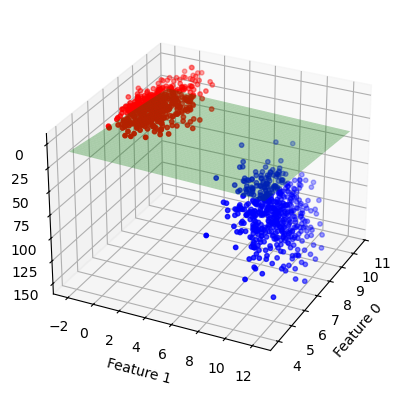

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import LinearSVC

X, Y = make_blobs(n_samples=1000, centers=2, random_state=8)
Y = Y % 2

linear_svm = LinearSVC().fit(X, Y)




X_new = np.hstack([X, (X[:, 1:] ** 2)])
linear_svm_3d = LinearSVC().fit(X_new, Y)

coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

figure = plt.figure()
ax = figure.add_subplot(111, projection='3d', elev=-152, azim=-26)


XX = np.linspace(X_new[:, 0].min() , X_new[:, 0].max() , 100)
YY = np.linspace(X_new[:, 1].min() , X_new[:, 1].max() , 100)
XX, YY = np.meshgrid(XX, YY)

ZZ = (-coef[0] * XX - coef[1] * YY - intercept) / coef[2]


ax.plot_surface(XX, YY, ZZ, alpha=0.3, color='g', linewidth=0, antialiased=True)

mask = Y == 0
print(mask)
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b', s=10)
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', s=10)

ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("Feature 1**2")
plt.show()
